<div align="center">

# **Linear Regression in PyTorch**

**Laboratory 4: Deep Learning Fundamentals**

</div>

This laboratory applies the PyTorch training workflow to a regression problem using the Advertising dataset. The model learns to predict sales from advertising expenditures in TV, radio, and newspaper media using two fully connected layers, Mean Squared Error loss, and Stochastic Gradient Descent.

## **Objectives**

By the end of this laboratory, the student should be able to:

- prepare a regression dataset for PyTorch;
- construct a regression model using fully connected layers;
- train the model using MSE Loss and SGD; and
- evaluate how well the trained model predicts continuous values.

## **Laboratory Problem**

> **Instruction:** Train a linear regression model in PyTorch using a regression dataset.

The model must use the following parameters:

| Parameter | Setting |
|---|---|
| Criterion | MSE Loss |
| Fully Connected Layers | 2 |
| Batch Size | 8 |
| Optimizer | SGD |
| Epochs | 1000 |

## **Concept Review**

### Regression Model Training in PyTorch

Regression is used when the target being predicted is a continuous numerical value. In PyTorch, a regression model learns by repeatedly passing input data through the network, measuring the difference between the predicted and actual values, propagating the error backward, and updating the model parameters.

A fully connected layer is implemented using `nn.Linear`, where every input feature is connected to the neurons in the next layer. This laboratory uses two fully connected layers to transform the input features into a single predicted value.

The model uses **Mean Squared Error (MSE)** as its loss function:

$$
\text{MSE}=\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

A lower MSE indicates that the predictions are closer to the actual target values. The parameters are updated using **Stochastic Gradient Descent (SGD)**, which moves the weights in the direction that reduces the loss:

$$
W_{\text{new}}=W_{\text{old}}-\alpha\frac{\partial L}{\partial W}
$$

Training is performed in batches of $8$ samples. One **epoch** represents one complete pass through the training dataset, and the model is trained for $1000$ epochs so that its parameters can be gradually refined.

## **Implementation**

#### **Import the Required Libraries**

PyTorch is used to build and train the regression model, while `scikit-learn` provides the California Housing dataset and tools for preparing the data.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
torch.manual_seed(42)
np.random.seed(42)

#### **Load the Dataset**

The Advertising dataset contains expenditures for TV, radio, and newspaper advertising together with the corresponding sales values. The advertising variables are used as input features, while `Sales` is used as the regression target.

In [3]:
df = pd.read_csv("data/MNIST/raw/Advertising.csv")

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


#### **Prepare the Features and Target**

The variables `TV`, `Radio`, and `Newspaper` are used as the model inputs, while `Sales` serves as the continuous target value.

In [6]:
X = df[["TV", "Radio", "Newspaper"]].values
y = df["Sales"].values.reshape(-1, 1)

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: (200, 3)
Target shape: (200, 1)


#### **Prepare the Training and Test Data**

The dataset is divided into training and test sets. The input features are standardized so that differences in their numerical scales do not dominate the SGD updates.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
#Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

print("Training inputs:", X_train.shape)
print("Training targets:", y_train.shape)

Training inputs: torch.Size([160, 3])
Training targets: torch.Size([160, 1])


#### **Create the DataLoader**

`TensorDataset` combines the training inputs and targets, while `DataLoader` organizes them into shuffled batches of $8$ samples as required by the laboratory.

In [9]:
train_dataset = TensorDataset(X_train, y_train)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

print("Number of batches:", len(train_loader))

Number of batches: 20


#### **Build the Regression Model**

The model uses two fully connected layers. The three advertising features are first mapped to eight intermediate units, followed by a second linear layer that produces one sales prediction.

In [10]:
class RegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(3, 8)
        self.fc2 = nn.Linear(8, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)

        return x


model = RegressionModel()

print(model)

RegressionModel(
  (fc1): Linear(in_features=3, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)


#### **Define the Loss Function and Optimizer**

Mean Squared Error is used as the criterion, while SGD is used to update the model parameters. Since the laboratory does not specify a learning rate, a value of $0.01$ is used.

In [11]:
criterion = nn.MSELoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01
)

#### **Train the Model**

The model is trained for $1000$ epochs. For each batch, the model performs a forward pass, calculates the MSE loss, computes the gradients through backpropagation, and updates the parameters using SGD.

In [ ]:
epochs = 1000
train_loss_history = []
test_loss_history = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for xb, yb in train_loader:
        # Forward pass
        pred = model(xb)

        # Compute loss
        loss = criterion(pred, yb)

        # Clear previous gradients
        optimizer.zero_grad()

        # Backward propagation
        loss.backward()

        # Update parameters
        optimizer.step()

        epoch_loss += loss.item()

    # Average train loss for the epoch
    train_mse = epoch_loss / len(train_loader)
    train_loss_history.append(train_mse)

    # Evaluate test loss for the epoch
    model.eval()
    with torch.no_grad():
        test_pred = model(X_test)
        test_mse = criterion(test_pred, y_test).item()
        test_loss_history.append(test_mse)

    # Print selected epochs
    if epoch == 0 or (epoch + 1) % 100 == 0:
        print(
            f"Epoch {epoch + 1:>4}/{epochs} | "
            f"Train Loss (MSE): {train_mse:.4f} | "
            f"Test Loss (MSE): {test_mse:.4f}"
        )

Epoch    1/1000 | Train MSE: 70.6995 | Test MSE: 3.0309
Epoch  100/1000 | Train MSE: 3.1067 | Test MSE: 3.2127
Epoch  200/1000 | Train MSE: 2.9260 | Test MSE: 3.1970
Epoch  300/1000 | Train MSE: 2.9799 | Test MSE: 3.8870
Epoch  400/1000 | Train MSE: 2.9399 | Test MSE: 3.4282
Epoch  500/1000 | Train MSE: 3.0858 | Test MSE: 3.4946
Epoch  600/1000 | Train MSE: 3.1396 | Test MSE: 3.1175
Epoch  700/1000 | Train MSE: 2.8883 | Test MSE: 3.3175
Epoch  800/1000 | Train MSE: 3.0951 | Test MSE: 3.4508
Epoch  900/1000 | Train MSE: 2.8847 | Test MSE: 3.0784
Epoch 1000/1000 | Train MSE: 2.8848 | Test MSE: 3.4786


#### **Training Loss**

The loss across the $1000$ epochs is plotted to observe how the model changes during training. A decreasing MSE indicates that the model is improving its predictions on the training data.

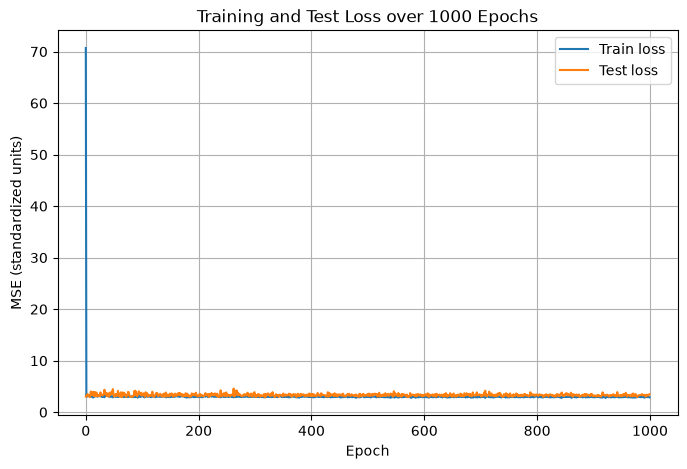

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(train_loss_history, label="Train loss")
plt.plot(test_loss_history, label="Test loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Test Loss over 1000 Epochs")
plt.legend()
plt.grid(True)

plt.show()

#### **Evaluate the Model**

The trained model is evaluated using the test data, which were not used to update the model parameters. This provides a measure of how well the learned relationship performs on unseen observations.

In [14]:
from sklearn.metrics import mean_squared_error, r2_score

model.eval()

with torch.no_grad():
    test_predictions = model(X_test)

y_true = y_test.numpy()
y_pred = test_predictions.numpy()

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print(f"Test MSE : {mse:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R²  : {r2:.4f}")

Test MSE : 3.4786
Test RMSE: 1.8651
Test R²  : 0.8898


In [15]:
for i in range(10):
    print(
        f"Actual: {y_test[i].item():.2f} | "
        f"Predicted: {test_predictions[i].item():.2f}"
    )

Actual: 16.90 | Predicted: 16.70
Actual: 22.40 | Predicted: 21.42
Actual: 21.40 | Predicted: 21.66
Actual: 7.30 | Predicted: 11.10
Actual: 24.70 | Predicted: 22.54
Actual: 12.60 | Predicted: 13.53
Actual: 22.30 | Predicted: 21.46
Actual: 8.40 | Predicted: 7.44
Actual: 11.50 | Predicted: 13.30
Actual: 14.90 | Predicted: 15.24


#### **Actual and Predicted Sales**

The actual sales values are compared with the model predictions to visually examine how closely the regression model follows the observed data.

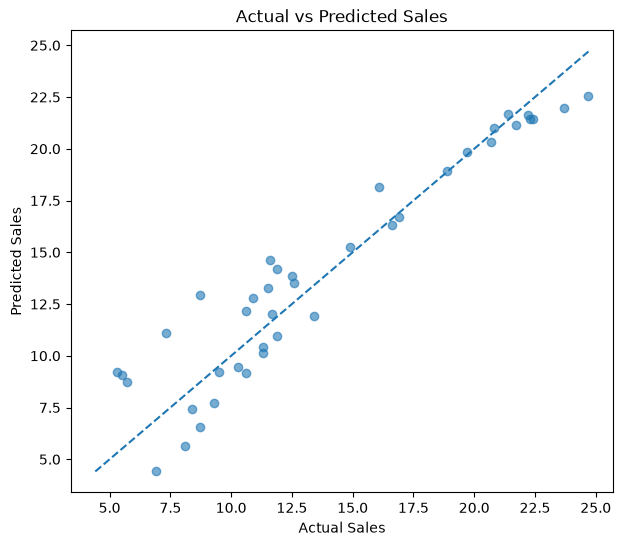

In [16]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test.numpy(),
    test_predictions.numpy(),
    alpha=0.6
)

min_value = min(y_test.min().item(), test_predictions.min().item())
max_value = max(y_test.max().item(), test_predictions.max().item())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

## **Results and Discussion**

The model showed a sharp reduction in training loss during the early epochs, indicating that it quickly learned the main linear relationship between advertising expenditures and sales. After this initial improvement, the training and test losses stabilized, with only small fluctuations caused by mini-batch SGD and data shuffling. At the end of training, the test MSE was approximately $3.4786$, with an RMSE of about $1.8651$ and an $R^2$ of $0.8898$. The RMSE indicates that the model's predictions differ from the actual sales values by about $1.87$ units on average, while the $R^2$ value shows that the model explains about $89\%$ of the variation in sales. The actual-versus-predicted plot also shows that most points are positioned close to the diagonal reference line, meaning that many predictions are reasonably close to their true values. Overall, the model learned the relationship in the dataset well, although some prediction errors remain because a simple linear model cannot perfectly capture every variation in sales.

## **Conclusion**

The laboratory demonstrated how a regression model can be trained in PyTorch using two fully connected layers, MSE Loss, SGD, mini-batches, and repeated epochs. The model was able to learn a strong relationship between advertising expenditures and sales, reaching a test MSE of about $3.4786$, an RMSE of $1.8651$, and an $R^2$ of $0.8898$. These results show that the model can explain most of the variation in sales, although some prediction error remains. Overall, the activity showed how the complete PyTorch training workflow can be applied to a real regression problem and evaluated using both numerical metrics and visual comparison.

This laboratory helped me understand how the different PyTorch components from the previous lessons work together in a full model-training process. I was able to see how the model repeatedly makes predictions, calculates the loss, performs backpropagation, and updates its parameters through SGD. The loss curve and evaluation metrics also made it easier to understand how model performance changes during training and how MSE, RMSE, and $R^2$ provide different ways of interpreting the final results.